**Eden's Github:** https://github.com/edenmhuang/DataJam_2024

# **April 1, 2024 - Monday Meeting - Updated Linear Regression and Scatter Plot**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.wkt import loads

import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
HEVs_per_Population_Income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/HEVs_per_Population_Income_2022.csv"

In [4]:
HEVs_per_Population_Income_df =  pd.read_csv(HEVs_per_Population_Income_link)

In [5]:
HEVs_per_Population_Income_df.head()

,Zip Code,Population,HEVs_per_Population,HEVs,Total Households,Median income (dollars)
0,94002,27893,0.151328,4221,10854,184929
1,94005,4756,0.170101,809,1902,137583
2,94010,43458,0.331308,14398,16070,186198
3,94014,46331,0.174311,8076,14014,111795
4,94015,65125,0.096752,6301,20476,117289


In [6]:
result = HEVs_per_Population_Income_df.groupby("Zip Code")["Median income (dollars)"].max()
result_sorted = result.sort_values(ascending=False)
top_10 = result_sorted.head(10)
print(top_10)



Zip Code
94020    250000
94027    250000
94028    243516
94062    230391
94070    220323
94018    215439
94025    207656
94021    201950
94065    201125
94010    186198
Name: Median income (dollars), dtype: int64


<Figure size 2000x2000 with 0 Axes>

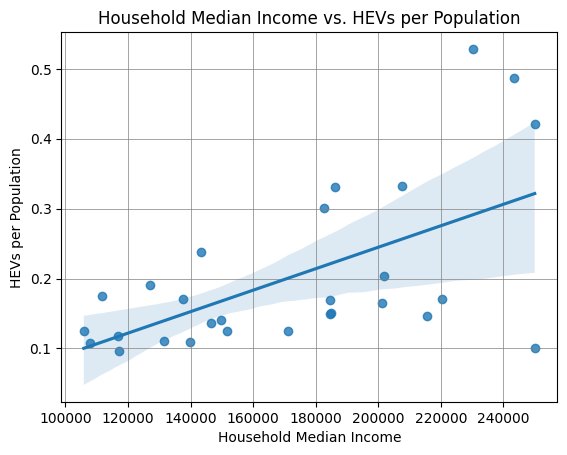

<Figure size 2000x2000 with 0 Axes>

In [7]:
sns.regplot( x = "Median income (dollars)", y = "HEVs_per_Population", data = HEVs_per_Population_Income_df).set_title("Household Median Income vs. HEVs per Population")
plt.xlabel("Household Median Income")
plt.ylabel("HEVs per Population")
plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=1)
plt.figure(figsize=(20, 20))

In [8]:
Y = HEVs_per_Population_Income_df['HEVs_per_Population']
X = HEVs_per_Population_Income_df['Median income (dollars)']
X = sm.add_constant(X)

reg_Equation = sm.OLS(Y,X).fit()
print(reg_Equation.summary())

                             OLS Regression Results                            
Dep. Variable:     HEVs_per_Population   R-squared:                       0.347
Model:                             OLS   Adj. R-squared:                  0.322
Method:                  Least Squares   F-statistic:                     13.81
Date:                 Wed, 03 Jun 2026   Prob (F-statistic):           0.000976
Time:                         22:36:26   Log-Likelihood:                 26.604
No. Observations:                   28   AIC:                            -49.21
Df Residuals:                       26   BIC:                            -46.54
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const           

/var/folders/j7/mw34xdm13nxcskrh8vbbjwqh0000gn/T/ipykernel_51366/3688082393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Zip Code", y="Median income (dollars)", data= HEVs_per_Population_Income_df, palette="deep")


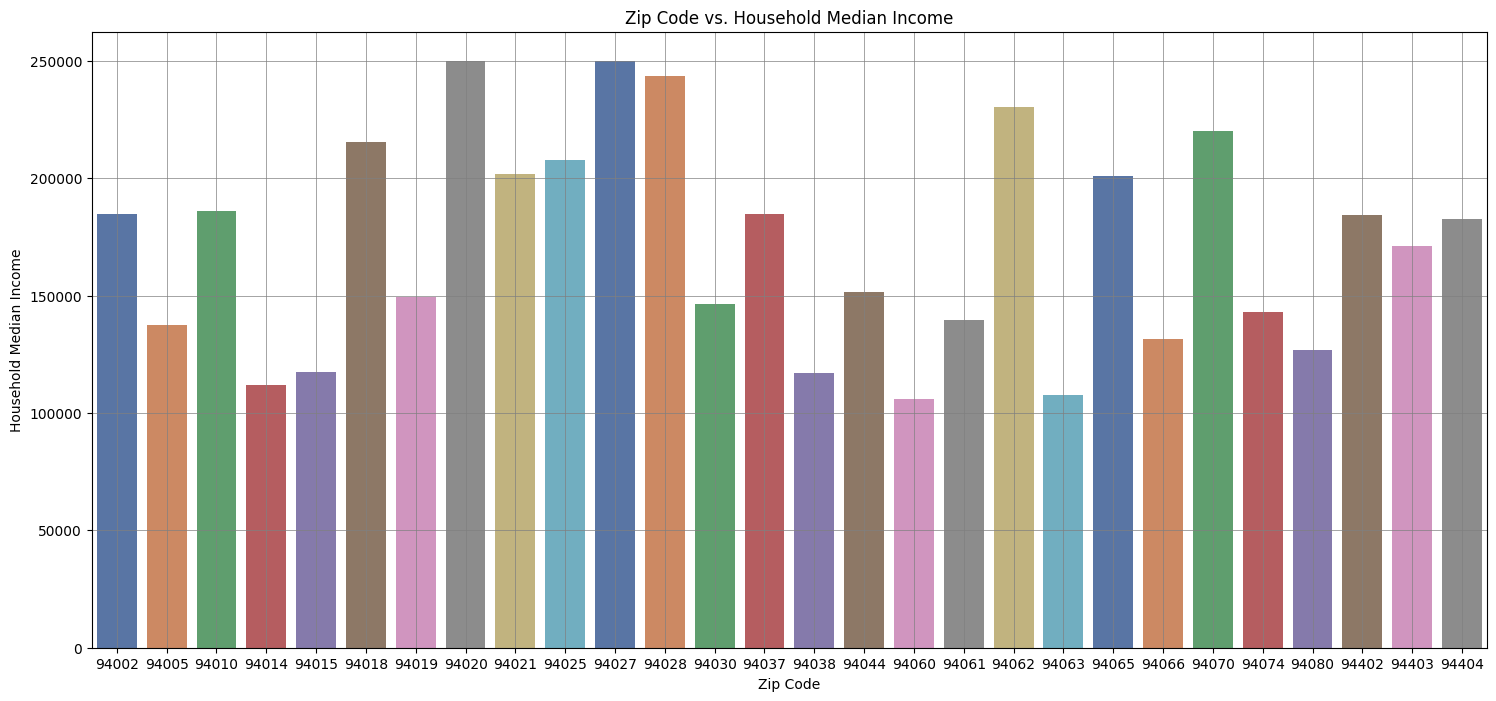

In [9]:
plt.figure(figsize=(18, 8))
sns.barplot(x="Zip Code", y="Median income (dollars)", data= HEVs_per_Population_Income_df, palette="deep")
plt.title("Zip Code vs. Household Median Income")
plt.xlabel("Zip Code")
plt.ylabel("Household Median Income")
plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=1)

plt.show()

# **March 22, 2024 - Friday Meeting - Linear Regression and Scatter Plot**

In [10]:
HEVs_Household_Income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/HEVs_Household_Income_2022.csv"

In [11]:
HEVs_Household_Income_df = pd.read_csv(HEVs_Household_Income_link)

In [12]:
HEVs_Household_Income_df.head()

,Zip Code,HEVs,Total Households,Median income (dollars),Mean income (dollars),the_geom
0,94002,4221,10854,184929,238074,MULTIPOLYGON (((-122.2682088446232 37.52821501...
1,94005,809,1902,137583,252170,MULTIPOLYGON (((-122.39113840779514 37.6931914...
2,94010,14398,16070,186198,297111,MULTIPOLYGON (((-122.3330402279353 37.58785711...
3,94014,8076,14014,111795,134129,MULTIPOLYGON (((-122.40826380425433 37.7023470...
4,94015,6301,20476,117289,147777,MULTIPOLYGON (((-122.46628479870415 37.6699110...


In [13]:
HEVs_Household_Income_df['the_geom'] = HEVs_Household_Income_df['the_geom'].apply(lambda geom_str: loads(geom_str))

# Check validity and apply buffer(0) if needed
for index, geom in HEVs_Household_Income_df['the_geom'].items():
    if not geom.is_valid:
        HEVs_Household_Income_df.at[index, 'the_geom'] = geom.buffer(0)

In [14]:
HEVs_Household_Income_df = gpd.GeoDataFrame(HEVs_Household_Income_df, geometry = 'the_geom')

In [15]:
HEVs_Household_Income_df.dtypes

Zip Code                      int64
HEVs                          int64
Total Households              int64
Median income (dollars)       int64
Mean income (dollars)         int64
the_geom                   geometry
dtype: object

<Figure size 2000x2000 with 0 Axes>

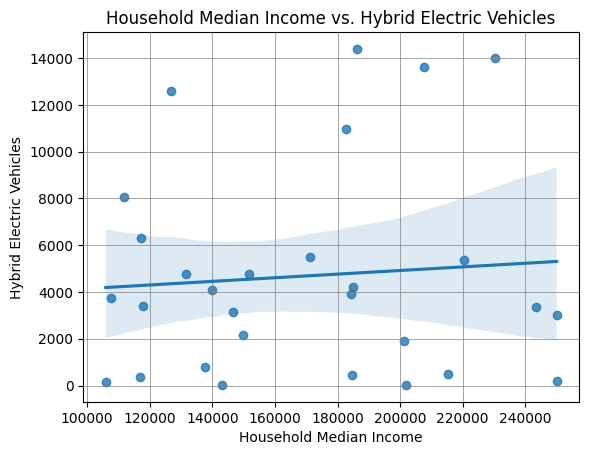

<Figure size 2000x2000 with 0 Axes>

In [16]:
sns.regplot( x = "Median income (dollars)", y = "HEVs", data = HEVs_Household_Income_df).set_title("Household Median Income vs. Hybrid Electric Vehicles")
plt.xlabel("Household Median Income")
plt.ylabel("Hybrid Electric Vehicles")
plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=1)
plt.figure(figsize=(20, 20))

In [17]:
Y = HEVs_Household_Income_df['HEVs']
X = HEVs_Household_Income_df['Median income (dollars)']
X = sm.add_constant(X)

reg_Equation = sm.OLS(Y,X).fit()
print(reg_Equation.summary())

                            OLS Regression Results                            
Dep. Variable:                   HEVs   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.031
Method:                 Least Squares   F-statistic:                    0.1693
Date:                Wed, 03 Jun 2026   Prob (F-statistic):              0.684
Time:                        22:36:27   Log-Likelihood:                -284.23
No. Observations:                  29   AIC:                             572.5
Df Residuals:                      27   BIC:                             575.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    3

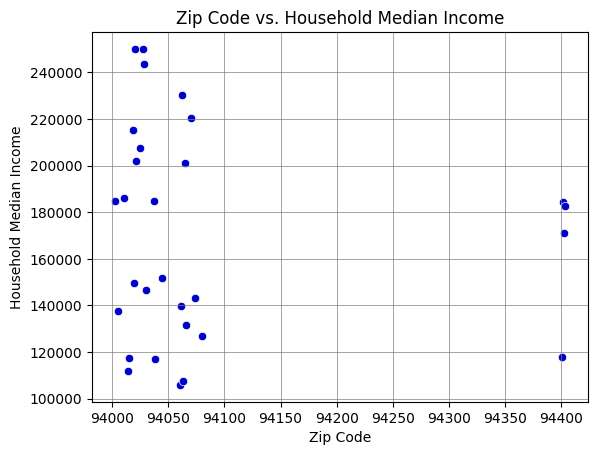

In [18]:
sns.scatterplot( x = "Zip Code", y = "Median income (dollars)", data = HEVs_Household_Income_df, color = "mediumblue").set_title("Zip Code vs. Household Median Income")
plt.xlabel("Zip Code")
plt.ylabel("Household Median Income")
plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=1)

 # **March 18, 2024 - Monday Meeting - Household Income Graph with Zip Code Labels**

In [19]:
SMC_Household_Income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/San_Mateo_County_Household_Income.csv"

In [20]:
SMC_Household_Income_df = pd.read_csv(SMC_Household_Income_link)

In [21]:
SMC_Household_Income_df.head()

,Zip Code,Total Households,Median income (dollars),Mean income (dollars),the_geom
0,94002,10854,184929,238074,MULTIPOLYGON (((-122.2682088446232 37.52821501...
1,94005,1902,137583,252170,MULTIPOLYGON (((-122.39113840779514 37.6931914...
2,94010,16070,186198,297111,MULTIPOLYGON (((-122.3330402279353 37.58785711...
3,94014,14014,111795,134129,MULTIPOLYGON (((-122.40826380425433 37.7023470...
4,94015,20476,117289,147777,MULTIPOLYGON (((-122.46628479870415 37.6699110...


In [22]:
# Assuming the DataFrame contains the geometry strings
# Convert the geometry strings to Shapely geometries
SMC_Household_Income_df['the_geom'] = SMC_Household_Income_df['the_geom'].apply(lambda geom_str: loads(geom_str))

# Check validity and apply buffer(0) if needed
for index, geom in SMC_Household_Income_df['the_geom'].items():
    if not geom.is_valid:
        SMC_Household_Income_df.at[index, 'the_geom'] = geom.buffer(0)

In [23]:
SMC_Household_Income_df = gpd.GeoDataFrame(SMC_Household_Income_df, geometry = 'the_geom')

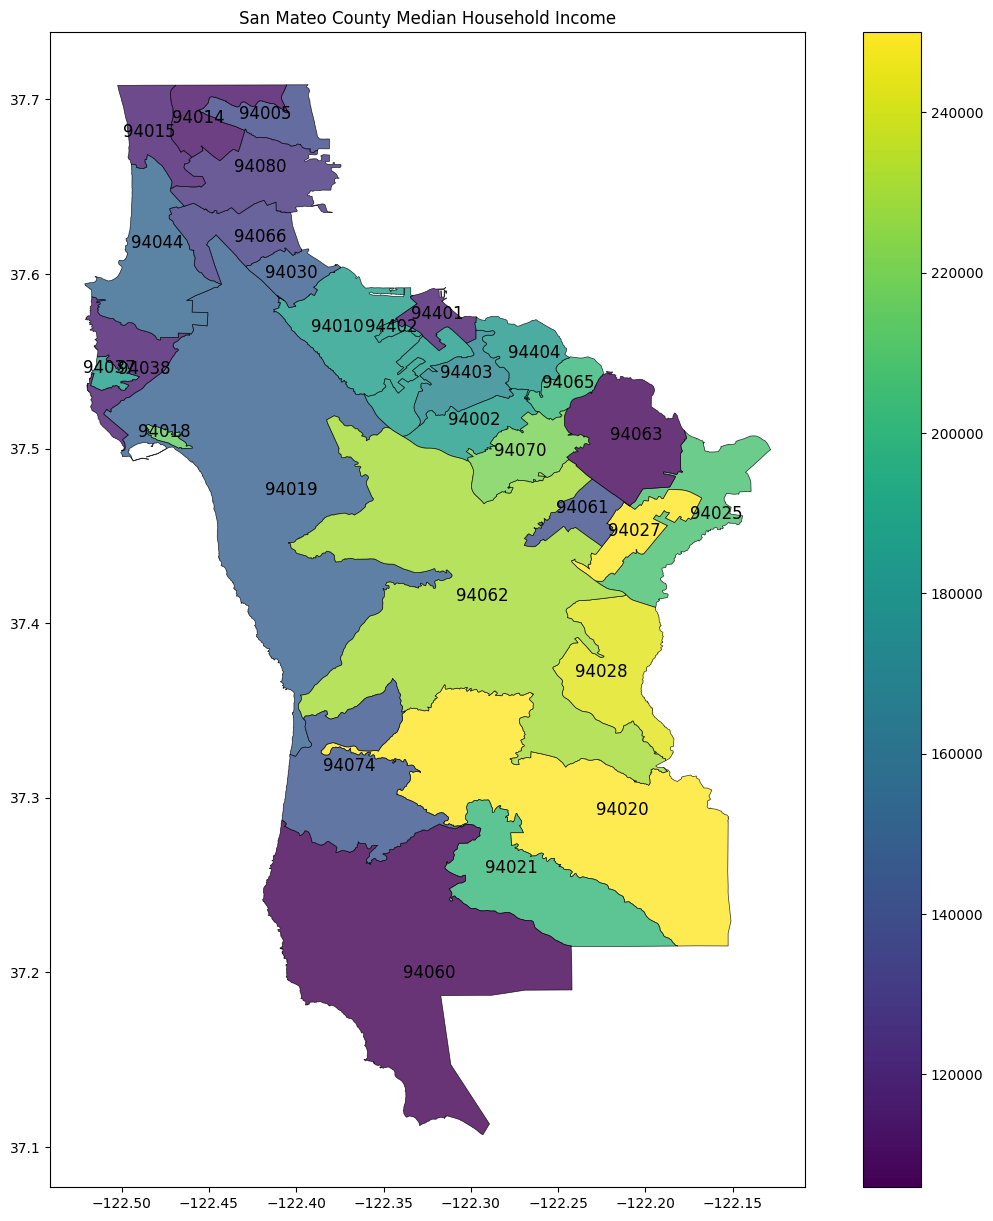

In [24]:
# Assuming SMC_Household_Income_df is a GeoDataFrame
SMC_Household_Income_df["coords"] = SMC_Household_Income_df["the_geom"].apply(lambda x: x.representative_point().coords[:])
SMC_Household_Income_df["coords"] = [coords[0] for coords in SMC_Household_Income_df["coords"]]

fig, ax = plt.subplots(figsize=(15, 15))  # Adjust the figure size as needed
SMC_Household_Income_df.plot(ax=ax, column='Median income (dollars)', legend=True, cmap='viridis', edgecolor="black", linewidth=0.5, alpha=0.8)

for idx, row in SMC_Household_Income_df.iterrows():
    # Calculate the centroid of the polygon
    centroid_x, centroid_y = row["coords"]
    # Shift the label position based on the polygon's centroid
    plt.annotate(text=row["Zip Code"], xy=(centroid_x, centroid_y), xytext=(0, 0), textcoords="offset points", fontsize=12, horizontalalignment="center", color="blacK")

plt.title('San Mateo County Median Household Income')
plt.show()

# **March 15, 2024 - Friday Meeting - Household Income Graph**



In [25]:
SMC_Household_Income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/San_Mateo_County_Household_Income.csv"

In [26]:
SMC_Household_Income_df = pd.read_csv(SMC_Household_Income_link)

In [27]:
SMC_Household_Income_df.head()

,Zip Code,Total Households,Median income (dollars),Mean income (dollars),the_geom
0,94002,10854,184929,238074,MULTIPOLYGON (((-122.2682088446232 37.52821501...
1,94005,1902,137583,252170,MULTIPOLYGON (((-122.39113840779514 37.6931914...
2,94010,16070,186198,297111,MULTIPOLYGON (((-122.3330402279353 37.58785711...
3,94014,14014,111795,134129,MULTIPOLYGON (((-122.40826380425433 37.7023470...
4,94015,20476,117289,147777,MULTIPOLYGON (((-122.46628479870415 37.6699110...


In [28]:
SMC_Household_Income_df.shape

(29, 5)

In [29]:
# Assuming the DataFrame contains the geometry strings
# Convert the geometry strings to Shapely geometries
SMC_Household_Income_df['the_geom'] = SMC_Household_Income_df['the_geom'].apply(lambda geom_str: loads(geom_str))

# Check validity and apply buffer(0) if needed
for index, geom in SMC_Household_Income_df['the_geom'].items():
    if not geom.is_valid:
        SMC_Household_Income_df.at[index, 'the_geom'] = geom.buffer(0)

In [30]:
SMC_Household_Income_df = gpd.GeoDataFrame(SMC_Household_Income_df, geometry = 'the_geom')

In [31]:
SMC_Household_Income_df.dtypes

Zip Code                      int64
Total Households              int64
Median income (dollars)       int64
Mean income (dollars)         int64
the_geom                   geometry
dtype: object

<Axes: >

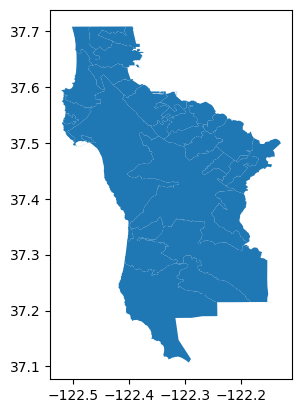

In [32]:
SMC_Household_Income_df.plot()

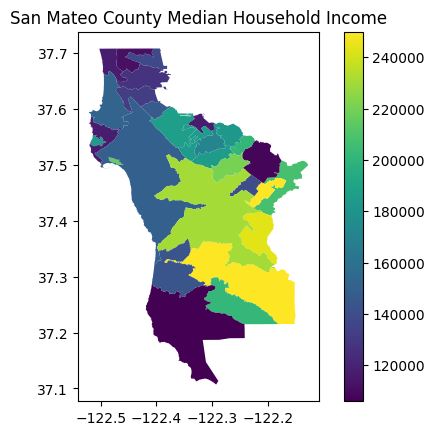

In [33]:
SMC_Household_Income_df.plot(column = 'Median income (dollars)', legend=True)
plt.title('San Mateo County Median Household Income')
plt.show()

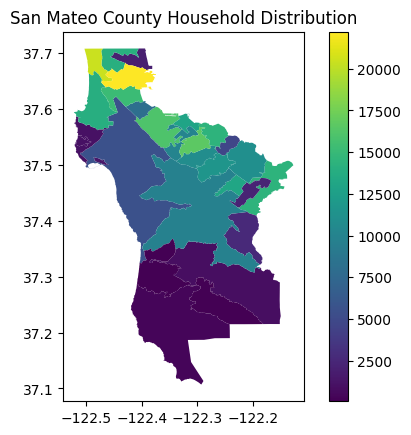

In [34]:
SMC_Household_Income_df.plot(column = 'Total Households', legend=True)
plt.title('San Mateo County Household Distribution')
plt.show()

# **March 11, 2024 - Monday Meeting - Full California Household Income Dataset**

In [35]:
Full_CA_Household_Income_link = "https://raw.githubusercontent.com/edenmhuang/DataJam_2024/main/CA_Household_Income_2022.csv"

In [36]:
Full_CA_Household_Income_df = pd.read_csv(Full_CA_Household_Income_link)

In [37]:
Full_CA_Household_Income_df.head()

,Zip Code,Total Households,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999","$200,000 or more",Median income (dollars),Mean income (dollars)
0,94002,10854,2.5%,3.5%,3.3%,2.8%,3.0%,7.2%,5.3%,13.3%,11.1%,48.0%,184929,238074
1,94005,1902,3.3%,0.0%,1.6%,0.0%,14.4%,10.9%,7.8%,16.1%,9.3%,36.6%,137583,252170
2,94010,16070,2.8%,0.8%,2.3%,2.5%,4.5%,7.7%,7.4%,12.6%,12.3%,47.1%,186198,297111
3,94014,14014,3.7%,3.3%,5.2%,5.0%,7.6%,9.6%,11.4%,19.0%,16.4%,18.9%,111795,134129
4,94015,20476,3.5%,2.1%,3.9%,4.1%,5.5%,10.3%,12.7%,20.2%,13.4%,24.3%,117289,147777


In [38]:
Full_CA_Household_Income_df.dtypes

Zip Code                     int64
Total Households             int64
    Less than $10,000       object
    $10,000 to $14,999      object
    $15,000 to $24,999      object
    $25,000 to $34,999      object
    $35,000 to $49,999      object
    $50,000 to $74,999      object
    $75,000 to $99,999      object
    $100,000 to $149,999    object
    $150,000 to $199,999    object
    $200,000 or more        object
Median income (dollars)      int64
Mean income (dollars)        int64
dtype: object